### Unsupervised Learning in Global mobile reviews Project

#### import the packages

In [19]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import plotly.express as px 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


###  Step - 1 - Data Collection: Load the dataset

In [2]:
global_mobile_review_data = pd.read_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_4-global_mobile_reviews\data\raw_data\Mobile_Reviews_Sentiment_null.csv")
global_mobile_review_dataframe = pd.DataFrame(global_mobile_review_data)
print("First five records:")
print(global_mobile_review_dataframe.head())

First five records:
   review_id      customer_name  age     brand          model  price_usd  \
0          1      Aryan Maharaj   45    Realme  Realme 12 Pro     337.31   
1          2  Davi Miguel Sousa   18    Realme  Realme 12 Pro     307.78   
2          3        Pahal Balay   27    Google        Pixel 6     864.53   
3          4       David Guzman   19    Xiaomi  Redmi Note 13     660.94   
4          5          Yago Leão   38  Motorola        Edge 50     792.13   

  price_local currency  exchange_rate_to_usd  rating  ...    language  \
0   ₹27996.73      INR                 83.00     2.0  ...       Hindi   
1   R$1754.35      BRL                  5.70     4.0  ...  Portuguese   
2   ₹71755.99      INR                 83.00     4.0  ...       Hindi   
3  د.إ2425.65      AED                  3.67     3.0  ...     English   
4   R$4515.14      BRL                  5.70     3.0  ...  Portuguese   

  review_date verified_purchase battery_life_rating  camera_rating  \
0   11/6/2023 

### Step - 2 - Data Understanding: Explore the data


In [3]:
print("Data Shape: ", global_mobile_review_dataframe.shape)
print("- " * 50)

print("\nData information: ")
print(global_mobile_review_dataframe.info())
print("- " * 50)

print("\nFind missing values: ")
print(global_mobile_review_dataframe.isnull().sum())
print("- " * 50)

print("\nFind Duplicate values: ")
print("No of Duplicate values present in the data :", global_mobile_review_dataframe.duplicated().sum())

Data Shape:  (50000, 22)
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Data information: 
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  str    
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  str    
 4   model                 50000 non-null  str    
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  str    
 7   currency              50000 non-null  str    
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  str    
 11  country               50000 non-null  str    
 12  language              50000 non-null 

The null values present in the Features are,

1. price_usd - 2450 ,
2. price_local - 2431 , 
3. rating - 2453 , 
4. sentiment - 2445 and 
5. source - 2448.

No of duplicate values in the data is 0.

### Step - 3 - Data Preparation:
#### Data Cleaning: 

#### 1 - Fill the null values in 'source' feature

In [4]:
# Fill null value in 'source' feature using mode():
# global_mobile_review_dataframe['source'] = global_mobile_review_dataframe['source'].fillna('Unknown')
global_mobile_review_dataframe['source'] = global_mobile_review_dataframe['source'].fillna(
                                            global_mobile_review_dataframe['source'].mode()[0])

print("\nMode value: ")

print(global_mobile_review_dataframe['source'].mode()[0])
print("- " * 50)

print("\nFind missing values: ")
print(global_mobile_review_dataframe.isnull().sum())


Mode value: 
eBay
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Find missing values: 
review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                     0
dtype: int64


#### 2 - Fill null values in 'rating' feature:

Calculating the mean value from the features, 

'battery_life_rating', 

'camera_rating', 

'performance_rating', 

'design_rating', 

'display_rating'  to clear missing values in 'rating'

In [5]:
# select the features, to calc. mean value and fill it in 'rating' feature:
rating_columns = ['battery_life_rating','camera_rating','performance_rating','design_rating','display_rating']
mean_rating = (global_mobile_review_dataframe[rating_columns].mean(axis=1))

global_mobile_review_dataframe['rating'] = global_mobile_review_dataframe['rating'].fillna(mean_rating).round().astype(int)

print("\nFind missing values: ")
print(global_mobile_review_dataframe.isnull().sum())
print("- " * 50)

print("\nInformation: ")
print(global_mobile_review_dataframe.info())



Find missing values: 


review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                     0
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                     0
dtype: int64
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Information: 
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 

#### 3 - Fill null values in 'sentiment' features:

Calculating mean value using features

'battery_life_rating',    

'camera_rating',   

'performance_rating',   

'design_rating',   

'display_rating',   

'helpful_votes'  to clear missing values in 'sentiment' features

In [6]:
# Select the features to calc mean value and fill in 'sentiment' features:
rating_columns_sentiment = ['battery_life_rating','camera_rating','performance_rating','design_rating','display_rating','helpful_votes']
sentiment_mean = (global_mobile_review_dataframe[rating_columns_sentiment].mean(axis=1))

def sentiment(avg_rating):
    if avg_rating > 3:
        return "Positive"
    elif avg_rating < 3:
        return "Negative"
    else :
        return "Neutral"
    
global_mobile_review_dataframe['sentiment'] = global_mobile_review_dataframe['sentiment'].fillna(sentiment_mean.apply(sentiment))

print("\nFind missing values: ")
print(global_mobile_review_dataframe.isnull().sum())



Find missing values: 
review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                     0
sentiment                  0
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                     0
dtype: int64


#### 4- Fill null values in 'price_usd' and create a new column 'price_local_value'

Split Currrency and Numeric value separately from 'Price_local'


In [7]:
# Split currency and numeric value seperately from 'price_local' feature:

def split_price_local(val):
    if pd.isna(val):
        return None, None
    val = str(val).strip()                         # removes extra spaces at end
    match = re.match(r'^([^\d]+)([\d,\.]+)$', val)
    if match:
        return match.group(1).strip(), float(match.group(2).replace(',', ''))
    return None, None

global_mobile_review_dataframe[['currency_symbol', 'price_local_value']] = global_mobile_review_dataframe['price_local'].apply(
                                    lambda x: pd.Series(split_price_local(x)))

print("\nFirst 5 rows: ")
print(global_mobile_review_dataframe.head(5))
print("- "*50)

print("\nInformation: ")
print(global_mobile_review_dataframe.info())
print("- "*50)

print("\nMissing values: ")
print(global_mobile_review_dataframe.isnull().sum())




First 5 rows: 
   review_id      customer_name  age     brand          model  price_usd  \
0          1      Aryan Maharaj   45    Realme  Realme 12 Pro     337.31   
1          2  Davi Miguel Sousa   18    Realme  Realme 12 Pro     307.78   
2          3        Pahal Balay   27    Google        Pixel 6     864.53   
3          4       David Guzman   19    Xiaomi  Redmi Note 13     660.94   
4          5          Yago Leão   38  Motorola        Edge 50     792.13   

  price_local currency  exchange_rate_to_usd  rating  ... verified_purchase  \
0   ₹27996.73      INR                 83.00       2  ...              True   
1   R$1754.35      BRL                  5.70       4  ...              True   
2   ₹71755.99      INR                 83.00       4  ...              True   
3  د.إ2425.65      AED                  3.67       3  ...             False   
4   R$4515.14      BRL                  5.70       3  ...              True   

  battery_life_rating camera_rating performance_rati

Clearing null values for 'price_usd' and 'price_local_value' features:

In [ ]:
# Fill value for 'price_local_value' by calculating 'price_usd' * 'exchange_rate_to_usd':
price_value_local = global_mobile_review_dataframe['price_usd'] * global_mobile_review_dataframe['exchange_rate_to_usd']
global_mobile_review_dataframe['price_local_value'] = global_mobile_review_dataframe['price_local_value'].fillna(price_value_local).round(2)

# Fill value for 'price_usd' by calculating 'price_local_value' / 'exchange_rate_to_usd':
price_value_usd_null = global_mobile_review_dataframe['price_local_value'] / global_mobile_review_dataframe['exchange_rate_to_usd']
global_mobile_review_dataframe['price_usd'] = global_mobile_review_dataframe['price_usd'].fillna(price_value_usd_null).round(2)

print("\nMissing Values: ")
print(global_mobile_review_dataframe.isnull().sum())
print("- "*50)


# Find mean value using 'model' and fill null value in 'price_usd':
price_usd_model_mean = global_mobile_review_dataframe.groupby('model')['price_usd'].transform('mean').round(2)
global_mobile_review_dataframe['price_usd'] = global_mobile_review_dataframe['price_usd'].fillna(price_usd_model_mean)


print("\nMissing Values: ")
print(global_mobile_review_dataframe.isnull().sum())
print("- "*50)

# Fill value for 'price_local_value' by calculating 'price_usd' * 'exchange_rate_to_usd':
price_local_mean = global_mobile_review_dataframe['price_usd'] * global_mobile_review_dataframe['exchange_rate_to_usd']
global_mobile_review_dataframe['price_local_value'] = global_mobile_review_dataframe['price_local_value'].fillna(price_local_mean.round(2))

print("\nMissing Values: ")
print(global_mobile_review_dataframe.isnull().sum())




Missing Values: 
review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd                123
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                     0
sentiment                  0
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                     0
currency_symbol         2431
price_local_value        123
dtype: int64
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Missing Values: 
review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd

#### Converting the review_date into day, month and year

In [9]:
# Converting the review_date into day, month and year:
global_mobile_review_dataframe['review_date'] = pd.to_datetime(global_mobile_review_dataframe['review_date'])

global_mobile_review_dataframe["day"] = global_mobile_review_dataframe["review_date"].dt.day
global_mobile_review_dataframe["month"] = global_mobile_review_dataframe["review_date"].dt.month
global_mobile_review_dataframe["year"] = global_mobile_review_dataframe["review_date"].dt.year

print("\nMissing values: ")
print(global_mobile_review_dataframe.isnull().sum())
print("- "*50)

print("\nInformation : ")
print(global_mobile_review_dataframe.info())
print("- "*50)

print("\nConverting datetype 'verified_purchase' from bool to int:")
global_mobile_review_dataframe['verified_purchase'] = global_mobile_review_dataframe['verified_purchase'].astype(int)
global_mobile_review_dataframe["year"] = global_mobile_review_dataframe["year"].astype(str)

print("\nInformation : ")
print(global_mobile_review_dataframe.info())
print("- "*50)

print("\nFirst 5 rows : ")
print(global_mobile_review_dataframe.head(5))



Missing values: 
review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd                  0
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                     0
sentiment                  0
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                     0
currency_symbol         2431
price_local_value          0
day                        0
month                      0
year                       0
dtype: int64
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Information : 
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data

#### Drop the unwanted columns:

In [10]:
global_mobile_review_dataframe = global_mobile_review_dataframe.drop(['price_local','currency_symbol'], axis = 1 )

# create a copy of original dataframe after clearing null values:
global_mobile_review_df = global_mobile_review_dataframe.copy()
global_mobile_review_df = global_mobile_review_df.drop(['review_id','customer_name','currency',
                                                        'review_date', 'exchange_rate_to_usd'], axis = 1)

print(global_mobile_review_df.isnull().sum())


age                    0
brand                  0
model                  0
price_usd              0
rating                 0
sentiment              0
country                0
language               0
verified_purchase      0
battery_life_rating    0
camera_rating          0
performance_rating     0
design_rating          0
display_rating         0
helpful_votes          0
source                 0
price_local_value      0
day                    0
month                  0
year                   0
dtype: int64


#### saved the processed dataset as a CSV file for future use

In [11]:
print("Data shape: ", global_mobile_review_df.shape)
print("- "*50)

print("\nInformation: ")
print(global_mobile_review_df.info())
print("- "*50)

print("\nFirst 5 rows: ")
print(global_mobile_review_df.head(5))

global_mobile_review_df.to_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_4-global_mobile_reviews\data\processed_data\Mobile_Reviews_Sentiment_before_encoding.csv",index = False)


Data shape:  (50000, 20)
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Information: 
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  50000 non-null  int64  
 1   brand                50000 non-null  str    
 2   model                50000 non-null  str    
 3   price_usd            50000 non-null  float64
 4   rating               50000 non-null  int64  
 5   sentiment            50000 non-null  str    
 6   country              50000 non-null  str    
 7   language             50000 non-null  str    
 8   verified_purchase    50000 non-null  int64  
 9   battery_life_rating  50000 non-null  int64  
 10  camera_rating        50000 non-null  int64  
 11  performance_rating   50000 non-null  int64  
 12  design_rating        50000 non-null  int64  
 13  displa

### Encoding process:

#### Label Encoding:

In [12]:
# label encoding:
global_mobile_review_encoded_df = global_mobile_review_df.copy()

print("\nLabel Encoding process: ")
print("\nLabel Encoding is done for 'sentiment' Features: ")

le = LabelEncoder()
# df['column_encoded'] = le.fit_transform(df['column'])
global_mobile_review_encoded_df['sentiments'] = (
                                   le.fit_transform(global_mobile_review_encoded_df['sentiment']))

print("\nAfter encoding:")
print("\nFirst Five Rows:")
print(global_mobile_review_encoded_df.head(5))
print("- "*50)

print("\nInformation: ")
print(global_mobile_review_encoded_df.info())

print("\ndrop sentiment feature: ")
global_mobile_review_encoded_df = global_mobile_review_encoded_df.drop(['sentiment'],axis=1)

print("\nInformation: ")
print(global_mobile_review_encoded_df.info())





Label Encoding process: 

Label Encoding is done for 'sentiment' Features: 

After encoding:

First Five Rows:
   age     brand          model  price_usd  rating sentiment country  \
0   45    Realme  Realme 12 Pro     337.31       2  Negative   India   
1   18    Realme  Realme 12 Pro     307.78       4  Positive  Brazil   
2   27    Google        Pixel 6     864.53       4  Positive   India   
3   19    Xiaomi  Redmi Note 13     660.94       3  Positive     UAE   
4   38  Motorola        Edge 50     792.13       3   Neutral  Brazil   

     language  verified_purchase  battery_life_rating  ...  \
0       Hindi                  1                    1  ...   
1  Portuguese                  1                    3  ...   
2       Hindi                  1                    3  ...   
3     English                  0                    1  ...   
4  Portuguese                  1                    3  ...   

   performance_rating  design_rating  display_rating  helpful_votes  \
0          

#### One hot encoding:

In [13]:
global_mobile_review_encoded_df = pd.get_dummies(global_mobile_review_encoded_df, 
                                                 columns=['brand', 'model', 'country', 'language','source'])

print("Data shape: ")
print(global_mobile_review_encoded_df.shape)
print("- "*50)

print("\nInformation:", )
print(global_mobile_review_encoded_df.info())
print("- "*50)

print("\nFirst 5 rows : ")
print(global_mobile_review_encoded_df.head(5))



Data shape: 
(50000, 61)
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

Information:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    50000 non-null  int64  
 1   price_usd              50000 non-null  float64
 2   rating                 50000 non-null  int64  
 3   verified_purchase      50000 non-null  int64  
 4   battery_life_rating    50000 non-null  int64  
 5   camera_rating          50000 non-null  int64  
 6   performance_rating     50000 non-null  int64  
 7   design_rating          50000 non-null  int64  
 8   display_rating         50000 non-null  int64  
 9   helpful_votes          50000 non-null  int64  
 10  price_local_value      50000 non-null  float64
 11  day                    50000 non-null  int32  
 12  month                  50000 

#### Saving dataset for future use:


In [14]:
global_mobile_review_encoded_df.to_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_4-global_mobile_reviews\data\processed_data\Mobile_Reviews_Sentiment_after_encoded_and_before_scaling.csv", index = False)


### Scaling:


In [ ]:
# Scaling the data

# If max is very far from 75% → outliers exist → StandardScaler
# If max is close to 75% → no big outliers → MinMaxScaler is fine
# choose MinMaxScaler if No significant outliers, want 0 to 1 range
# choose StandardScaler if Data has outliers, want balanced distances 

print(global_mobile_review_encoded_df['price_usd'].describe())

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
global_mobile_review_encoded_df_scaled = scaler.fit_transform(global_mobile_review_encoded_df)

count    50000.000000
mean       689.695291
std        310.102320
min        180.020000
25%        450.727500
50%        637.125000
75%        900.667500
max       1499.890000
Name: price_usd, dtype: float64


In [16]:
df_scaled_df = pd.DataFrame(global_mobile_review_encoded_df_scaled, columns=global_mobile_review_encoded_df.columns)
df_scaled_df.to_csv(r'C:\Users\jagad\Documents\my_classes\Tasks\mini_project_4-global_mobile_reviews\data\processed_data\Mobile_Reviews_Sentiment_cleaned_data.csv', index=False)

print(df_scaled_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    50000 non-null  float64
 1   price_usd              50000 non-null  float64
 2   rating                 50000 non-null  float64
 3   verified_purchase      50000 non-null  float64
 4   battery_life_rating    50000 non-null  float64
 5   camera_rating          50000 non-null  float64
 6   performance_rating     50000 non-null  float64
 7   design_rating          50000 non-null  float64
 8   display_rating         50000 non-null  float64
 9   helpful_votes          50000 non-null  float64
 10  price_local_value      50000 non-null  float64
 11  day                    50000 non-null  float64
 12  month                  50000 non-null  float64
 13  year                   50000 non-null  float64
 14  sentiments             50000 non-null  float64
 15  brand_Apple  

### Feature selection:

In [17]:
global_mobile_review_model_df = global_mobile_review_encoded.copy()
print(global_mobile_review_model_df.info())
global_mobile_review_model_df = global_mobile_review_model_df.drop(['customer_name','brand','model','price_local','exchange_rate_to_usd',
                                        'currency','sentiment','country','language','review_date','verified_purchase',
                                        'source','currency_symbol','review_dates'], axis=1)

print(global_mobile_review_model_df.info())


NameError: name 'global_mobile_review_encoded' is not defined

### Correlation matrix for Clustering:

In [ ]:
model_correlation_column = ['review_id','age','price_usd','rating','battery_life_rating','camera_rating','performance_rating',
                            'design_rating','display_rating','helpful_votes','price_local_value','day','month','year','brand_encoded',
                            'model_encoded','currency_encoded','sentiment_encoded','country_encoded','language_encoded',
                            'verified_purchase_encoded','source_encoded','customer_id']

clustering_model_correlation_matrix = global_mobile_review_model_df[model_correlation_column].corr()

#Heatmap for correlation:
clustering_correlation_heatmap_fig = px.imshow(clustering_model_correlation_matrix, 
                                                 title='Correlation Analysis for Clustering Model',
                                                 color_continuous_scale="RDBu_r",
                                                 color_continuous_midpoint=0,
                                                 labels = dict(color="Correlation",fontsize = 10, fontweight = 'bold'),
                                                 text_auto='.2f',
                                                 aspect="equal"                              
                                                  )
clustering_correlation_heatmap_fig.update_layout(title_x = 0.30,
                                                   width=1050,
                                                   height=1000,
                                                   xaxis=dict(tickangle=-90),
                                                   coloraxis_colorbar=dict(
                                                   len=0.9,                      
                                                   yanchor="middle",             
                                                   y=0.5     )
                                                      )
clustering_correlation_heatmap_fig.show()



### Model Building:

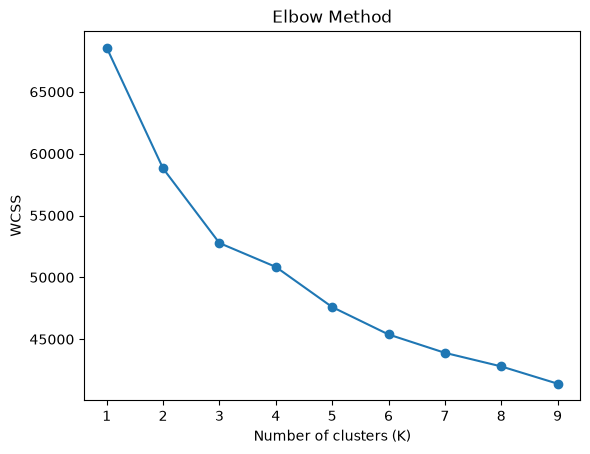

[[0.57446809 0.11917083 0.25       ... 0.66666667 1.         0.25      ]
 [0.         0.09679741 0.75       ... 1.         1.         0.75      ]
 [0.19148936 0.51861926 0.75       ... 0.66666667 1.         0.        ]
 ...
 [0.06382979 0.73893641 0.75       ... 0.         1.         0.25      ]
 [0.27659574 0.21139961 0.5        ... 0.         1.         1.        ]
 [0.55319149 0.15163615 1.         ... 0.         1.         0.5       ]]


In [ ]:
feature_for_modelling  = ['age','price_usd','rating','helpful_votes','day','month','year','brand_encoded',
                            'model_encoded','sentiment_encoded','country_encoded','language_encoded',
                            'verified_purchase_encoded','source_encoded']

X = global_mobile_review_model_df[feature_for_modelling]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

SSE = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    SSE.append(kmeans.inertia_)   # inertia_ = SSE

plt.plot(K_range, SSE, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

print(X_scaled)



In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
global_mobile_review_model_df['cluster'] = kmeans.fit_predict(X_scaled)

# cluster_names = {0:"A", 1:"B"}
# global_mobile_review_model_df['cluster_group'] = global_mobile_review_model_df['cluster'].map(cluster_names)

print(global_mobile_review_model_df.head())



   review_id  age  price_usd  rating  battery_life_rating  camera_rating  \
0          1   45     337.31     2.0                    1              1   
1          2   18     307.78     4.0                    3              2   
2          3   27     864.53     4.0                    3              5   
3          4   19     660.94     3.0                    1              3   
4          5   38     792.13     3.0                    3              3   

   performance_rating  design_rating  display_rating  helpful_votes  ...  \
0                   3              2               1              1  ...   
1                   4              3               2              5  ...   
2                   3              2               4              8  ...   
3                   2              1               2              3  ...   
4                   2              2               1              0  ...   

   brand_encoded  model_encoded  currency_encoded  sentiment_encoded  \
0             

In [ ]:
# print(silhouette_score(X_scaled,global_mobile_review_model_df['cluster']))

In [ ]:
cluster_profile = (
    global_mobile_review_model_df.groupby('cluster')[feature_for_modelling]
      .mean()
      .round(2)
)

cluster_profile

,age,price_usd,rating,helpful_votes,day,month,year,brand_encoded,model_encoded,sentiment_encoded,country_encoded,language_encoded,verified_purchase_encoded,source_encoded
cluster,,,,,,,,,,,,,,
0,29.99,685.94,2.01,2.02,15.66,6.50,2023.81,3.03,10.68,0.50,3.45,0.80,0.0,2.12
1,30.02,691.99,3.95,4.89,15.64,6.48,2023.81,2.98,10.77,1.96,3.50,0.75,0.0,2.10
2,30.05,689.92,3.65,4.17,15.54,6.59,2023.79,3.02,10.77,1.71,2.32,2.56,1.0,2.12
3,30.12,689.31,1.94,1.99,15.68,6.51,2023.81,2.99,10.70,0.46,3.71,0.54,1.0,2.12
4,30.08,690.12,3.96,4.90,15.80,6.51,2023.80,3.00,10.72,1.96,3.85,0.16,1.0,2.07


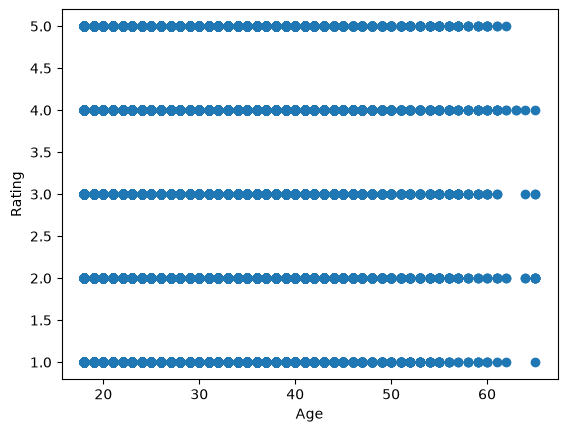

In [ ]:
plt.scatter(global_mobile_review_model_df['age'], global_mobile_review_model_df['rating'])
plt.xlabel("Age")
plt.ylabel("Rating")
plt.show()

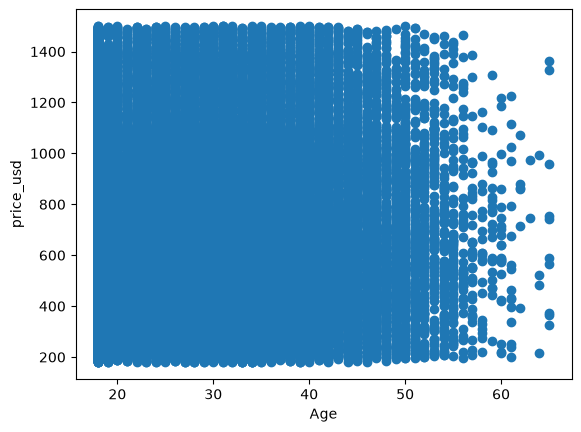

In [ ]:
plt.scatter(global_mobile_review_model_df['age'], global_mobile_review_model_df['price_usd'])
plt.xlabel("Age")
plt.ylabel("price_usd")
plt.show()

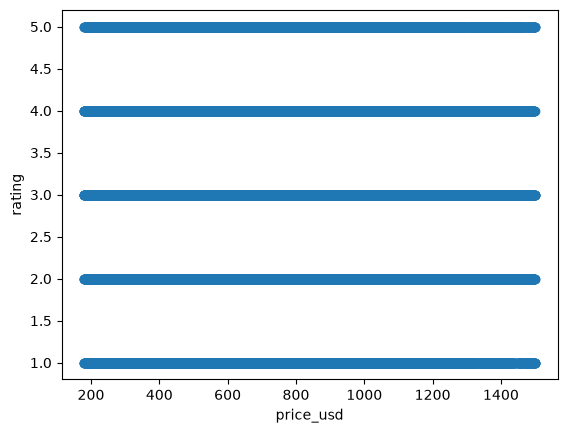

In [ ]:
plt.scatter(global_mobile_review_model_df['price_usd'], global_mobile_review_model_df['rating'])
plt.xlabel("price_usd")
plt.ylabel("rating")
plt.show()